In [86]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import joblib

In [87]:
data = pd.read_csv(r"/content/adult 3.csv")

In [88]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [89]:
data.replace('?', np.nan, inplace=True)

In [90]:
data['occupation'].fillna('Others', inplace=True)
data['workclass'].fillna('Notlisted', inplace=True)

/tmp/ipython-input-90-230017677.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['occupation'].fillna('Others', inplace=True)
/tmp/ipython-input-90-230017677.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [91]:
data = data[~data['workclass'].isin(['Without-pay', 'Never-worked'])]

In [92]:
data = data[~data['education'].isin(['5th-6th', '1st-4th', 'Preschool'])]

In [93]:
data.drop(columns=['education'], inplace=True)

In [94]:
data = data[(data['age'] >= 17) & (data['age'] <= 75)]

In [95]:
encoder = LabelEncoder()
for col in ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']:
    data[col] = encoder.fit_transform(data[col])

In [96]:
data

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,7,4,6,3,2,1,0,0,40,38,<=50K
1,38,3,89814,9,2,4,0,4,1,0,0,50,38,<=50K
2,28,1,336951,12,2,11,0,4,1,0,0,40,38,>50K
3,44,3,160323,10,2,6,0,2,1,7688,0,40,38,>50K
4,18,2,103497,10,4,8,3,4,0,0,0,30,38,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,12,2,13,5,4,0,0,0,38,38,<=50K
48838,40,3,154374,9,2,6,0,4,1,0,0,40,38,>50K
48839,58,3,151910,9,6,0,4,4,0,0,0,40,38,<=50K
48840,22,3,201490,9,4,0,3,4,1,0,0,20,38,<=50K


In [97]:
x = data.drop(columns=['income'])
y = data['income']

In [98]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
# Scale features
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [99]:
#Split data
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=23, stratify=y)

In [100]:
data

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,7,4,6,3,2,1,0,0,40,38,<=50K
1,38,3,89814,9,2,4,0,4,1,0,0,50,38,<=50K
2,28,1,336951,12,2,11,0,4,1,0,0,40,38,>50K
3,44,3,160323,10,2,6,0,2,1,7688,0,40,38,>50K
4,18,2,103497,10,4,8,3,4,0,0,0,30,38,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,12,2,13,5,4,0,0,0,38,38,<=50K
48838,40,3,154374,9,2,6,0,4,1,0,0,40,38,>50K
48839,58,3,151910,9,6,0,4,4,0,0,0,40,38,<=50K
48840,22,3,201490,9,4,0,3,4,1,0,0,20,38,<=50K


In [101]:
# Train multiple models and evaluate
models = {
    "KNN": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "MLPClassifier": MLPClassifier(solver='adam', hidden_layer_sizes=(5,2), random_state=2, max_iter=2000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, pred))


KNN Accuracy: 0.8169
              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.88      7206
        >50K       0.64      0.57      0.60      2318

    accuracy                           0.82      9524
   macro avg       0.75      0.73      0.74      9524
weighted avg       0.81      0.82      0.81      9524

LogisticRegression Accuracy: 0.8202
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89      7206
        >50K       0.71      0.44      0.54      2318

    accuracy                           0.82      9524
   macro avg       0.78      0.69      0.72      9524
weighted avg       0.81      0.82      0.80      9524

MLPClassifier Accuracy: 0.8415
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      7206
        >50K       0.73      0.55      0.63      2318

    accuracy                           0.84      9524
   macro avg       0.80      0.74      0

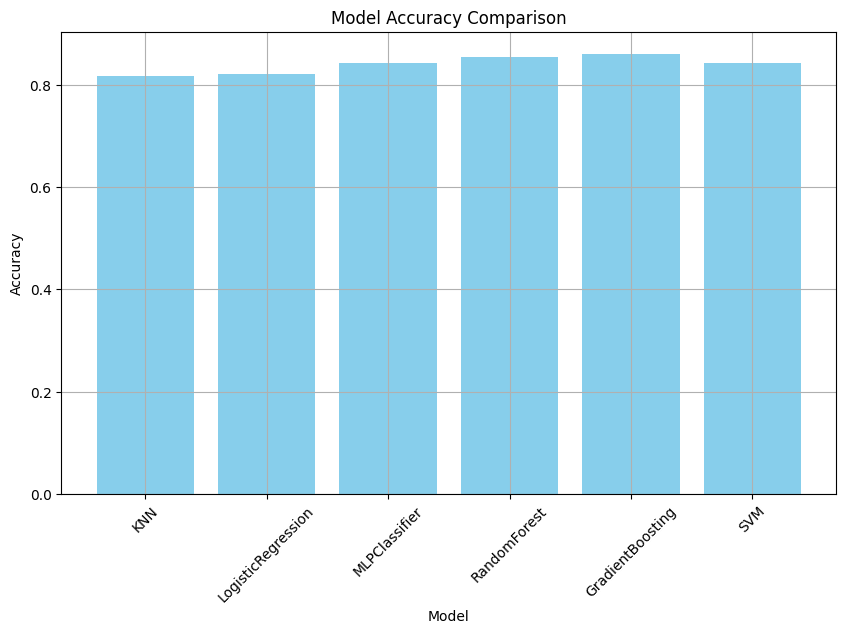

In [102]:
# Plot model comparison
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [103]:
# Select best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"✅ Best Model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

✅ Best Model: GradientBoosting with accuracy 0.8600


In [104]:
# Save best model and scaler for deployment
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Best model and scaler saved successfully.")

✅ Best model and scaler saved successfully.


In [105]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

#Load the trained model
modle=joblib.load("best_model.pkl")

st.set_page_config(page_title="Employee Salary Classification",page_icon="💼",layout="centered")
st.title("💼 Employee Salary Classification App")
st.markdown("Predict whether an employee earns >50K or ≤50K based on input features.")

# Sidebar inputs (these must match your training feature columns)
st.sidebar.header("Input Employee Details")

# Replace these fields with your dataset's actual input columns
age = st.sidebar.slider("Age", 18, 65, 30)
education = st.sidebar.selectbox("Education Level", [
    "Bachelors", "Masters", "PhD", "HS-grad", "Assoc", "Some-college"
])
occupation = st.sidebar.selectbox("Job Role", [
    "Tech-support", "Craft-repair", "Other-service", "Sales",
    "Exec-managerial", "Prof-specialty", "Handlers-cleaners", "Machine-op-inspct",
    "Adm-clerical", "Farming-fishing", "Transport-moving", "Priv-house-serv",
    "Protective-serv", "Armed-Forces"
])

hours_per_week = st.sidebar.slider("Hours per week", 1, 80, 40)
experience = st.sidebar.slider("Years of Experience", 0, 40, 5)

# Build input DataFrame (must match preprocessing of your training data)
input_df = pd.DataFrame({
    'age': [age],
    'education': [education],
    'occupation': [occupation],
    'hours-per-week': [hours_per_week],
    'experience': [experience]
})

st.write("### Input Data")
st.write(input_df)

# Predict button
if st.button("Predict Salary Class"):
    prediction = model.predict(input_df)
    st.success(f"💰 Prediction: {prediction[0]}")

#Batch prediction
st.markdown("---")
st.markdown("### Batch Prediction")
uploaded_file = st.file_uploader("Upload a CSV file for batch prediction", type="csv")

if uploaded_file is not None:
    batch_data = pd.read_csv(uploaded_file)
    st.write("Upload data preview:",batch_data.head())
    batch_preds=model.predict(batch_data)
    batch_data['PredictedClass']=batch_preds
    st.write("Predictions:")
    st.write(batch_data.head())
    csv=batch_data.to_csv(index=False).encode('utf-8')
    st.download_button("Download Predictions",csv,file_name='predicted_classes.csv',mime='text/csv')

Overwriting app.py


In [106]:
!pip install streamlit pyngrok

In [107]:
!ngrok authtoken 30BtvPE5E1J4IIXAO9aehHImy0M_3WowjDjMCSHjuGjjgjKXf

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [108]:
import os
import threading

def run_streamlit():
    os.system('streamlit run app.py --server.port 8501')

thread = threading.Thread(target=run_streamlit)
thread.start()

In [109]:
from pyngrok import ngrok
import time

# Wait a few seconds to ensure Streamlit has started
time.sleep(5)

# Create a tunnel to the Streamlit  port 8501
public_url = ngrok.connect(8501)
print("✅ Your Streamlit app is live at:", public_url)


✅ Your Streamlit app is live at: NgrokTunnel: "https://50292784310a.ngrok-free.app" -> "http://localhost:8501"
